In [1]:
import torch                          # import torch library
import torch.nn as nn                 # import nn module for creating layers, models and functions
import numpy as np                    # import numpy library
from torch.autograd import Variable   # variable from numpy to torch
import matplotlib.pyplot as plt       # import pyplot library

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # set GPU as processing device
print(device)

cuda:0


In [3]:
epochs = 4000  # number of training epochs
col_p  = 750  # number of collocation points
input_size = 1
hidden_size = 25

E   = 21e9            # Pa  (Young Modulus)
I   = (.10*.15**3/12) # m^4 (Beam inertia)
L   = 3               # m   (Beam length)
q_0 = 10000           # N/m (Punctual load q)

class NN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(NN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, hidden_size)
        self.fc5 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        x = self.fc5(x)
        return x

In [4]:
### (2) Model
# Create the neural network and move it to the GPU if available
NN = NN(input_size, hidden_size).to(device)
NN = NN.to(device)                                       # transfer net to GPU for processing
mse_cost_function = torch.nn.MSELoss()                   # mean squared error as loss function
optimizer = torch.optim.Adam(NN.parameters(), lr=0.001)  # Adam optimizer for parameter updating

In [5]:
## PDE as loss function.
def f(x, NN, E, I, q_0, L):
    v = NN(x) # the dependent variable u is given by the network based on independent variable x
    ## Based on our f = E*I*d4v/dx4 - (q_0/L)*x, we need d4v/dx4
    v_x  = torch.autograd.grad(v.sum(),x, create_graph=True)[0]    # dv/dx
    v_x2 = torch.autograd.grad(v_x.sum(),x,create_graph=True)[0]   # d2v/dx2
    v_x3 = torch.autograd.grad(v_x2.sum(),x,create_graph=True)[0]  # d3v/dx3
    v_x4 = torch.autograd.grad(v_x3.sum(),x,create_graph=True)[0]  # d4v/dx4
    pde  = E*I*v_x4 + (q_0/L)*x                        
    return pde

In [6]:
## Data from Boundary Conditions
## BC gives us datapoints for training
## We will find out v(x) for x in range [0,L]

# Define normalization parameters
x_min = 0  # Minimum value of the input
x_max = L  # Maximum value of the input (in this case, the beam length)

#################################### 1. x=0, v(0)=0 ####################################
x_bc1  = np.zeros((col_p,1))         # Take say 200 random numbers of (x,v)
v_bc1  = np.zeros((col_p,1))         # Compute v based on BC

#################################### 2. x=0, dv/dx=0 ###################################
x_bc2   = np.zeros((col_p,1))        # Take say 200 random numbers of (x,v)
v_x_bc2 = np.zeros((col_p,1))        # Compute dv/dx based on BC

#################################### 3. x=L, EI*d3v/dx3=0 ###############################
x_bc3    = L*np.ones((col_p,1))      # Take say 200 random numbers of (x,v)
v_x3_bc3 = np.zeros((col_p,1))       # Compute d3v/dx3 based on BC

#################################### 4. x=L, EI*d2v/dx2=0 ##############################
x_bc4    = L*np.ones((col_p,1))      # Take say 200 random numbers of (x,v)
v_x2_bc4 = np.zeros((col_p,1))       # Compute d2v/dx2 based on BC

# Normalize the input data for boundary conditions
x_bc1_n = (x_bc1 - x_min) / (x_max - x_min)
x_bc2_n = (x_bc2 - x_min) / (x_max - x_min)
x_bc3_n = (x_bc3 - x_min) / (x_max - x_min)
x_bc4_n = (x_bc4 - x_min) / (x_max - x_min)

In [7]:
### (3) Training / Fitting
Loss_track = []                    # Initialize empty list for gathering loss values

for epoch in range(epochs):
    optimizer.zero_grad() # to make the gradients zero
    
    # Loss based on boundary conditions
    # BC 1.    
    pt_x_bc1   = Variable(torch.from_numpy(x_bc1_n).float(), requires_grad=True).to(device)
    pt_v_bc1   = Variable(torch.from_numpy(v_bc1).float(), requires_grad=False).to(device)
    
    NN_bc1_out = NN(pt_x_bc1) # output NN(x) --> v
    mse_u1     = mse_cost_function(NN_bc1_out, pt_v_bc1)
    
    # BC 2.
    pt_x_bc2   = Variable(torch.from_numpy(x_bc2_n).float(), requires_grad=True).to(device)
    pt_v_x_bc2 = Variable(torch.from_numpy(v_x_bc2).float(), requires_grad=False).to(device)
    
    NN_bc2_out = NN(pt_x_bc2) # output NN(x) --> v
    dv_x_bc2   = torch.autograd.grad(NN_bc2_out.sum(),pt_x_bc2,create_graph=True)[0]
    mse_u2     = mse_cost_function(dv_x_bc2, pt_v_x_bc2)
    
    # BC 3.
    pt_x_bc3   = Variable(torch.from_numpy(x_bc3_n).float(), requires_grad=True).to(device)
    pt_v_x3_bc3= Variable(torch.from_numpy(v_x3_bc3).float(), requires_grad=False).to(device)
    
    NN_bc3_out = NN(pt_x_bc3) # output NN(x) --> v
    dv_x_bc3   = torch.autograd.grad(NN_bc3_out.sum(),pt_x_bc3,create_graph=True)[0]
    dv_x2_bc3  = torch.autograd.grad(dv_x_bc3.sum(),pt_x_bc3,create_graph=True)[0]
    dv_x3_bc3  = torch.autograd.grad(dv_x2_bc3.sum(),pt_x_bc3,create_graph=True)[0]
    mse_u3     = mse_cost_function(dv_x3_bc3, pt_v_x3_bc3)
        
    # BC 4.
    pt_x_bc4   = Variable(torch.from_numpy(x_bc4_n).float(), requires_grad=True).to(device)
    pt_v_x2_bc4 = Variable(torch.from_numpy(v_x2_bc4).float(), requires_grad=False).to(device)
    
    NN_bc4_out = NN(pt_x_bc4) # output NN(x) --> v
    dv_x_bc4   = torch.autograd.grad(NN_bc4_out.sum(),pt_x_bc4,create_graph=True)[0]
    dv_x2_bc4  = torch.autograd.grad(dv_x_bc4.sum(),pt_x_bc4,create_graph=True)[0]
    mse_u4     = mse_cost_function(dv_x2_bc4, pt_v_x2_bc4)
    
    # Loss based on PDE
    x_col        = np.linspace(0.0, L, col_p).reshape((col_p,1))
    x_col_n      = (x_col - x_min) / (x_max - x_min)
    all_zeros    = np.zeros((col_p,1))
    pt_x_col     = Variable(torch.from_numpy(x_col_n).float(), requires_grad=True).to(device)
    pt_all_zeros = Variable(torch.from_numpy(all_zeros).float(), requires_grad=False).to(device)
    
    f_out        = f(pt_x_col,NN,E,I,q_0,L)                # output of f(x)
    mse_f        = mse_cost_function(f_out, pt_all_zeros)
    
    # Combining the loss functions
    loss = mse_u1 + mse_u2 + mse_u3 + mse_u4 + mse_f
    
    loss.backward()  # This is for computing gradients using backward propagation
    optimizer.step() # This is equivalent to: theta_new = theta_old - alpha * derivative of J w.r.t theta
    
    loss_np = loss.data.cpu().numpy()          # Torch tensors to Numpy
    Loss_track = np.append(Loss_track,loss_np) # Tracking loss values and creating a list
    
    with torch.autograd.no_grad():
        if epoch % 10 == 0: print(epoch,"Traning Loss:",loss.data) # Print loss every 10 epochs

0 Traning Loss: tensor(3643243.2500, device='cuda:0')
10 Traning Loss: tensor(3191849., device='cuda:0')
20 Traning Loss: tensor(2422609.5000, device='cuda:0')
30 Traning Loss: tensor(1301268.2500, device='cuda:0')
40 Traning Loss: tensor(687657.3125, device='cuda:0')
50 Traning Loss: tensor(350077.8750, device='cuda:0')
60 Traning Loss: tensor(126519.9141, device='cuda:0')
70 Traning Loss: tensor(43967.4023, device='cuda:0')
80 Traning Loss: tensor(52326.5977, device='cuda:0')
90 Traning Loss: tensor(44487.8984, device='cuda:0')
100 Traning Loss: tensor(41882.7227, device='cuda:0')
110 Traning Loss: tensor(41586.0977, device='cuda:0')
120 Traning Loss: tensor(40470.8906, device='cuda:0')
130 Traning Loss: tensor(39888.9180, device='cuda:0')
140 Traning Loss: tensor(39296.6758, device='cuda:0')
150 Traning Loss: tensor(38687.2461, device='cuda:0')
160 Traning Loss: tensor(38084.5312, device='cuda:0')
170 Traning Loss: tensor(37461.4453, device='cuda:0')
180 Traning Loss: tensor(36828.0

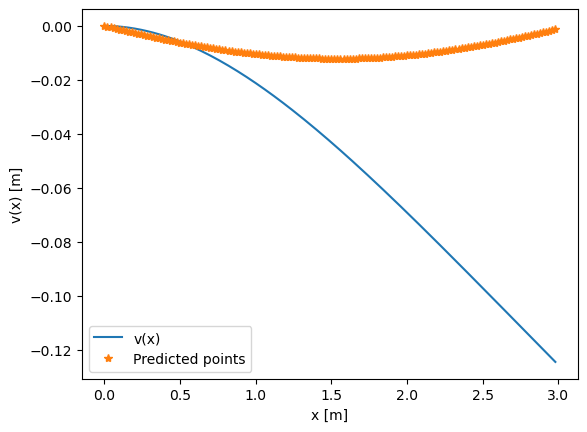

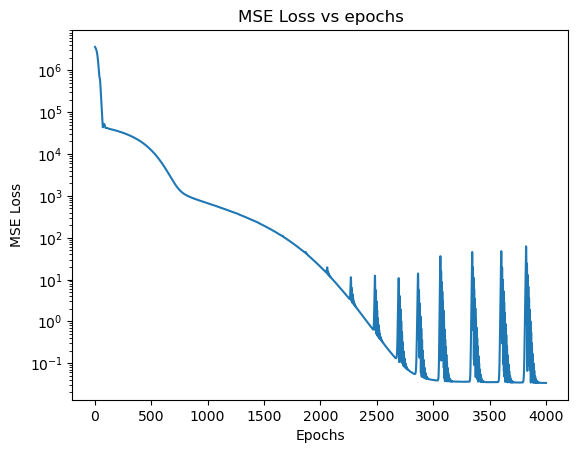

In [8]:
#### Plotting results ###

# Differential equation vs Predicted results
x = np.arange(0,L,0.02)
y = -q_0*(x**5)/(120*E*I*L)+q_0*L*(x**3)/(12*E*I)-q_0*(L**2)*(x**2)/(6*E*I)
x = x.reshape(-1,1)

pt_x = Variable(torch.from_numpy(x).float(), requires_grad=True).to(device)
pt_v = NN(pt_x)
v    = pt_v.data.cpu().numpy()

plt.plot(x,y)
plt.plot(x,v,'*')
plt.xlabel('x [m]')
plt.ylabel('v(x) [m]')
plt.legend(['v(x)','Predicted points'])
plt.show()

#Loss graphics
ep = np.linspace(1,epochs,epochs)
plt.semilogy(ep,Loss_track)
plt.title('MSE Loss vs epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.show()